# 🔬 Oral Cancer Classification: Baseline vs QI-IncepNet Benchmark
### Dataset: Kaggle OSCC Histopathology (Normal vs OSCC)
**Architectures compared:**
- Baseline 1: InceptionV3 (fine-tuned)
- Baseline 2: EfficientNetB3
- Proposed: QI-IncepNet (InceptionV3 + SE + CBAM + Quantum Layer)

**Metrics reported:** Accuracy, Precision, Recall, F1-Score, AUC-ROC  
**Format:** IEEE-ready comparison table at the end


## Cell 1 — Install Dependencies

In [ ]:
# Install required libraries
# PennyLane is needed for the quantum layer in QI-IncepNet
!pip install kaggle --quiet

import os
print("✅ Dependencies installed")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.9 MB/s eta 0:00:00
✅ Dependencies installed


## Cell 2 — Download Kaggle OSCC Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Google Drive mounted!")

Mounted at /content/drive
✅ Google Drive mounted!


In [ ]:
import os

SAVE_DIR = '/content/drive/MyDrive/oral_cancer_models'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"✅ Folder created: {SAVE_DIR}")

✅ Folder created: /content/drive/MyDrive/oral_cancer_models


In [ ]:
import os

# Set the API token as environment variable
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_3e96f021ebfee8e85198acd69fb2519e'

# Create kaggle.json from the token
import json
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({"key": "KGAT_3e96f021ebfee8e85198acd69fb2519e"}, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Done!")

Done!


In [ ]:
!kaggle datasets download -d zaidpy/oral-cancer-dataset
!unzip oral-cancer-dataset.zip -d ./oral_cancer_data

Dataset URL: https://www.kaggle.com/datasets/zaidpy/oral-cancer-dataset
License(s): apache-2.0
100% 315M/315M [00:01<00:00, 189MB/s]

Archive:  oral-cancer-dataset.zip
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/001.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/002.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/003.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/004.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/005.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/006.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/007.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/008.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/009.jpeg  
  inflating: ./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER/010.jpeg  
  inflating:

In [ ]:
import os

# Count all images
total = 0
for root, dirs, files in os.walk('./oral_cancer_data'):
    images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    total += len(images)
    if images:
        print(f"{root}: {len(images)} images")

print(f"\n✅ Total images: {total}")

./oral_cancer_data/Oral cancer Dataset 2.0/OC Dataset kaggle new/CANCER: 500 images
./oral_cancer_data/Oral cancer Dataset 2.0/OC Dataset kaggle new/NON CANCER: 450 images
./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/CANCER: 500 images
./oral_cancer_data/Oral Cancer/Oral Cancer Dataset/NON CANCER: 250 images

✅ Total images: 1700


In [ ]:
!kaggle datasets list --search "oral cancer"

ref                                                          title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
ankushpanday2/oral-cancer-prediction-dataset                 Oral Cancer Prediction Dataset                         2249627  2025-03-06 14:13:24.547000           4825         58                1  
zaidpy/oral-cancer-dataset                                   ORAL CANCER DATASET                                  330205351  2024-02-27 23:38:30.843000           4257         30            0.625  
shivam17299/oral-cancer-lips-and-tongue-images               Oral Cancer (Lips and Tongue) images                  29044168  2020-10-06 14:03:48.163000           4712         47             0.75  
ashenafifasilke

In [ ]:
!rm -rf ./oral_cancer_data

!kaggle datasets download -d raymanodeep/oral-cancer-v2-part-1
!unzip oral-cancer-v2-part-1.zip -d ./oral_cancer_data

Dataset URL: https://www.kaggle.com/datasets/raymanodeep/oral-cancer-v2-part-1
License(s): CC0-1.0
100% 213M/213M [00:01<00:00, 168MB/s]

Archive:  oral-cancer-v2-part-1.zip
  inflating: ./oral_cancer_data/dataset/cancer/cancer (1).gif  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (1).jpeg  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (1).jpg  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (1).png  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (1).webp  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (10).gif  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (10).jpeg  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (10).jpg  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (100).jpeg  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (100).jpg  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (100).png  
  inflating: ./oral_cancer_data/dataset/cancer/cancer (1000).jpg  
  inflating: ./oral_cancer_data/dataset/ca

In [ ]:
import os
total = 0
for root, dirs, files in os.walk('./oral_cancer_data'):
    images = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    total += len(images)
    if images:
        print(f"{root}: {len(images)} images")
print(f"\n✅ Total images: {total}")

./oral_cancer_data/dataset/cancer: 1466 images
./oral_cancer_data/dataset/non-cancer: 540 images

✅ Total images: 2006


In [ ]:
# Dataset 3 - muhammadatef (206MB)
!kaggle datasets download -d muhammadatef/oral-cancer-images-for-classification
!unzip -q oral-cancer-images-for-classification.zip -d ./data3

# Dataset 4 - fatmaahmedabdallah
!kaggle datasets download -d fatmaahmedabdallah/oral-cancer-dataset
!unzip -q oral-cancer-dataset.zip -d ./data4

Dataset URL: https://www.kaggle.com/datasets/muhammadatef/oral-cancer-images-for-classification
License(s): apache-2.0
100% 197M/197M [00:01<00:00, 110MB/s]

Dataset URL: https://www.kaggle.com/datasets/fatmaahmedabdallah/oral-cancer-dataset
License(s): apache-2.0
File already downloaded completely.


In [ ]:
import os, shutil

# Create unified dataset folders
os.makedirs('./final_dataset/cancer', exist_ok=True)
os.makedirs('./final_dataset/non_cancer', exist_ok=True)

def copy_images(src_root, cancer_keywords=['cancer', 'CANCER', 'Cancer'],
                non_cancer_keywords=['non', 'NON', 'Non', 'normal', 'NORMAL']):
    counter = {'cancer': 0, 'non_cancer': 0}
    for root, dirs, files in os.walk(src_root):
        for file in files:
            if not file.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            src = os.path.join(root, file)
            folder = os.path.basename(root)

            if any(k in folder for k in non_cancer_keywords):
                dst = f"./final_dataset/non_cancer/{counter['non_cancer']}_{file}"
                shutil.copy2(src, dst)
                counter['non_cancer'] += 1
            elif any(k in folder for k in cancer_keywords):
                dst = f"./final_dataset/cancer/{counter['cancer']}_{file}"
                shutil.copy2(src, dst)
                counter['cancer'] += 1
    return counter

# Copy from all sources
for folder in ['./oral_cancer_data', './data3', './data4']:
    if os.path.exists(folder):
        result = copy_images(folder)
        print(f"{folder}: Cancer={result['cancer']}, Non-Cancer={result['non_cancer']}")

./oral_cancer_data: Cancer=1466, Non-Cancer=540
./data3: Cancer=682, Non-Cancer=551
./data4: Cancer=1000, Non-Cancer=700


In [ ]:
cancer_count = len(os.listdir('./final_dataset/cancer'))
non_cancer_count = len(os.listdir('./final_dataset/non_cancer'))

print(f"🔴 Cancer images     : {cancer_count}")
print(f"🟢 Non-Cancer images : {non_cancer_count}")
print(f"📦 Total             : {cancer_count + non_cancer_count}")
print(f"⚖️  Ratio             : {cancer_count/non_cancer_count:.2f}:1")

🔴 Cancer images     : 3147
🟢 Non-Cancer images : 1789
📦 Total             : 4936
⚖️  Ratio             : 1.76:1


# Handle the imbalance with Data Augmentation

In [ ]:
import os, shutil
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
import numpy as np

def augment_class(src_folder, target_count):
    images = os.listdir(src_folder)
    current = len(images)
    if current >= target_count:
        print(f"✅ {src_folder} already has {current} images, no augmentation needed")
        return

    datagen = ImageDataGenerator(
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )

    needed = target_count - current
    print(f"🔄 Generating {needed} new images for {os.path.basename(src_folder)}...")

    counter = 0
    while counter < needed:
        img_path = os.path.join(src_folder, images[counter % current])
        img = load_img(img_path, target_size=(224, 224))
        x = img_to_array(img)
        x = x.reshape((1,) + x.shape)

        for batch in datagen.flow(x, batch_size=1,
                                   save_to_dir=src_folder,
                                   save_prefix='aug',
                                   save_format='jpg'):
            counter += 1
            break
        if counter % 100 == 0:
            print(f"  Generated {counter}/{needed}")

    print(f"✅ Done! {os.path.basename(src_folder)} now has {len(os.listdir(src_folder))} images")

# Balance both classes to 3147 (the majority class count)
augment_class('./final_dataset/non_cancer', 3147)

🔄 Generating 1358 new images for non_cancer...
  Generated 100/1358
  Generated 200/1358
  Generated 300/1358
  Generated 400/1358
  Generated 500/1358
  Generated 600/1358
  Generated 700/1358
  Generated 800/1358
  Generated 900/1358
  Generated 1000/1358
  Generated 1100/1358
  Generated 1200/1358
  Generated 1300/1358
✅ Done! non_cancer now has 3049 images


In [ ]:
cancer_count = len(os.listdir('./final_dataset/cancer'))
non_cancer_count = len(os.listdir('./final_dataset/non_cancer'))
print(f"🔴 Cancer     : {cancer_count}")
print(f"🟢 Non-Cancer : {non_cancer_count}")
print(f"📦 Total      : {cancer_count + non_cancer_count}")
print(f"⚖️  Ratio      : {cancer_count/non_cancer_count:.2f}:1")

🔴 Cancer     : 3147
🟢 Non-Cancer : 3049
📦 Total      : 6196
⚖️  Ratio      : 1.03:1


# Setup & Data Preparation

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (ResNet50, VGG16, InceptionV3,
                                           MobileNetV2, EfficientNetB0, DenseNet121)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported!")
print(f"TensorFlow version: {tf.__version__}")

✅ All libraries imported!
TensorFlow version: 2.19.0


# Data Generators

In [ ]:
DATASET_PATH = './final_dataset'
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training',
    seed=42
)

val_gen = test_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation',
    seed=42,
    shuffle=False
)

print(f"\n📦 Training samples   : {train_gen.samples}")
print(f"📦 Validation samples : {val_gen.samples}")
print(f"🏷️  Classes            : {train_gen.class_indices}")

Found 4958 images belonging to 2 classes.
Found 1238 images belonging to 2 classes.

📦 Training samples   : 4958
📦 Validation samples : 1238
🏷️  Classes            : {'cancer': 0, 'non_cancer': 1}


# Model Builder Function

In [ ]:
def build_model(base_model_fn, input_shape=(224, 224, 3), name="model"):
    base = base_model_fn(weights='imagenet', include_top=False, input_shape=input_shape)

    # Freeze base model layers
    for layer in base.layers:
        layer.trainable = False

    x = base.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base.input, outputs=output, name=name)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

print("✅ Model builder ready!")

✅ Model builder ready!


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import (ResNet50, VGG16, InceptionV3,
                                           MobileNetV2, EfficientNetB0, DenseNet121)
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Constants ──────────────────────────────────────
DATASET_PATH = './final_dataset'
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 50

# ── Data Generators ────────────────────────────────
train_datagen = ImageDataGenerator(
    rescale=1./255, validation_split=0.2,
    rotation_range=20, zoom_range=0.2,
    horizontal_flip=True, brightness_range=[0.8, 1.2], fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', seed=42
)
val_gen = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

# ── Model Builder ──────────────────────────────────
def build_model(base_model_fn, input_shape=(224, 224, 3), name="model"):
    base = base_model_fn(weights='imagenet', include_top=False, input_shape=input_shape)
    for layer in base.layers:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=base.input, outputs=output, name=name)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

# ── Callbacks ──────────────────────────────────────
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(f'./{model_name}_best.h5', monitor='val_accuracy',
                        save_best_only=True, verbose=0)
    ]

# ── Results Storage ────────────────────────────────
results   = {}
histories = {}

print("✅ All setup complete! Ready to train.")
print(f"📦 Train: {train_gen.samples} | Val: {val_gen.samples}")
print(f"🏷️  Classes: {train_gen.class_indices}")

Found 4958 images belonging to 2 classes.
Found 1238 images belonging to 2 classes.
✅ All setup complete! Ready to train.
📦 Train: 4958 | Val: 1238
🏷️  Classes: {'cancer': 0, 'non_cancer': 1}


# MobileNetV2

In [ ]:
tf.keras.backend.clear_session()

model_name = 'MobileNetV2'
model = build_model(MobileNetV2, name=model_name)

history_mobilenet = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks(model_name), verbose=1
)

val_gen.reset()
eval_results = model.evaluate(val_gen, verbose=0)
results['MobileNetV2'] = {
    'accuracy'  : round(eval_results[1] * 100, 2),
    'auc'       : round(eval_results[2] * 100, 2),
    'precision' : round(eval_results[3] * 100, 2),
    'recall'    : round(eval_results[4] * 100, 2),
}
histories['MobileNetV2'] = history_mobilenet
print(f"✅ MobileNetV2 → Accuracy: {results['MobileNetV2']['accuracy']}%")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.7756 - auc: 0.8494 - loss: 0.5138 - precision: 0.7768 - recall: 0.7422

156/156 ━━━━━━━━━━━━━━━━━━━━ 177s 975ms/step - accuracy: 0.8185 - auc: 0.8960 - loss: 0.4312 - precision: 0.8252 - recall: 0.8023 - val_accuracy: 0.8551 - val_auc: 0.9398 - val_loss: 0.3312 - val_precision: 0.9108 - val_recall: 0.7830 - learning_rate: 0.0010
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.8651 - auc: 0.9366 - loss: 0.3293 - precision: 0.8592 - recall: 0.8711

156/156 ━━━━━━━━━━━━━━━━━━━━ 114s 733ms/step - accuracy: 0.8748 - auc: 0.9437 - loss: 0.3068 - precision: 0.8735 - recall: 0.8728 - val_accuracy: 0.8639 - val_auc: 0.9462 - val_loss: 0.3265 - val_precision: 0.9405 - val_recall: 0.7732 - learning_rate: 0.0010
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 652ms/step - accuracy: 0.8989 - auc: 0.9570 - loss: 0.2654 - precision: 0.9096 - recall: 0.8826

156/156 ━━━━━━━━━━━━━━━━━━━━ 114s 731ms/step - accuracy: 0.8938 - auc: 0.9547 - loss: 0.2740 - precision: 0.8995 - recall: 0.8834 - val_accuracy: 0.8792 - val_auc: 0.9611 - val_loss: 0.2744 - val_precision: 0.9410 - val_recall: 0.8059 - learning_rate: 0.0010
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 111s 711ms/step - accuracy: 0.9038 - auc: 0.9679 - loss: 0.2292 - precision: 0.9099 - recall: 0.8936 - val_accuracy: 0.8752 - val_auc: 0.9645 - val_loss: 0.2827 - val_precision: 0.9490 - val_recall: 0.7896 - learning_rate: 0.0010
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 110s 705ms/step - accuracy: 0.9135 - auc: 0.9710 - loss: 0.2178 - precision: 0.9199 - recall: 0.9034 - val_accuracy: 0.8792 - val_auc: 0.9648 - val_loss: 0.2924 - val_precision: 0.9621 - val_recall: 0.7863 - learning_rate: 0.0010
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.9162 - auc: 0.9721 - loss: 0.2141 - precision: 0.9214 - recall: 0.9091
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002000

156/156 ━━━━━━━━━━━━━━━━━━━━ 109s 698ms/step - accuracy: 0.9167 - auc: 0.9742 - loss: 0.2038 - precision: 0.9211 - recall: 0.9091 - val_accuracy: 0.8857 - val_auc: 0.9652 - val_loss: 0.2790 - val_precision: 0.9627 - val_recall: 0.7993 - learning_rate: 0.0010
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 639ms/step - accuracy: 0.9302 - auc: 0.9836 - loss: 0.1648 - precision: 0.9416 - recall: 0.9164

...

156/156 ━━━━━━━━━━━━━━━━━━━━ 120s 764ms/step - accuracy: 0.9443 - auc: 0.9866 - loss: 0.1459 - precision: 0.9507 - recall: 0.9356 - val_accuracy: 0.9026 - val_auc: 0.9733 - val_loss: 0.2511 - val_precision: 0.9731 - val_recall: 0.8254 - learning_rate: 4.0000e-05
Epoch 13/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - accuracy: 0.9483 - auc: 0.9865 - loss: 0.1429 - precision: 0.9541 - recall: 0.9407

156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 692ms/step - accuracy: 0.9453 - auc: 0.9869 - loss: 0.1425 - precision: 0.9504 - recall: 0.9380 - val_accuracy: 0.9034 - val_auc: 0.9743 - val_loss: 0.2485 - val_precision: 0.9731 - val_recall: 0.8271 - learning_rate: 4.0000e-05
Epoch 14/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 106s 677ms/step - accuracy: 0.9443 - auc: 0.9863 - loss: 0.1462 - precision: 0.9474 - recall: 0.9393 - val_accuracy: 0.9026 - val_auc: 0.9751 - val_loss: 0.2445 - val_precision: 0.9713 - val_recall: 0.8271 - learning_rate: 4.0000e-05
Epoch 15/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9428 - auc: 0.9857 - loss: 0.1480 - precision: 0.9444 - recall: 0.9388

156/156 ━━━━━━━━━━━━━━━━━━━━ 105s 673ms/step - accuracy: 0.9435 - auc: 0.9878 - loss: 0.1398 - precision: 0.9458 - recall: 0.9393 - val_accuracy: 0.9042 - val_auc: 0.9760 - val_loss: 0.2418 - val_precision: 0.9714 - val_recall: 0.8303 - learning_rate: 4.0000e-05
Epoch 16/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.9487 - auc: 0.9889 - loss: 0.1336 - precision: 0.9572 - recall: 0.9397

156/156 ━━━━━━━━━━━━━━━━━━━━ 116s 747ms/step - accuracy: 0.9465 - auc: 0.9887 - loss: 0.1341 - precision: 0.9513 - recall: 0.9397 - val_accuracy: 0.9090 - val_auc: 0.9759 - val_loss: 0.2412 - val_precision: 0.9717 - val_recall: 0.8401 - learning_rate: 4.0000e-05
Epoch 17/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 106s 683ms/step - accuracy: 0.9475 - auc: 0.9884 - loss: 0.1349 - precision: 0.9521 - recall: 0.9409 - val_accuracy: 0.9082 - val_auc: 0.9764 - val_loss: 0.2394 - val_precision: 0.9716 - val_recall: 0.8385 - learning_rate: 4.0000e-05
Epoch 18/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.9460 - auc: 0.9865 - loss: 0.1469 - precision: 0.9506 - recall: 0.9402

156/156 ━━━━━━━━━━━━━━━━━━━━ 104s 665ms/step - accuracy: 0.9499 - auc: 0.9878 - loss: 0.1384 - precision: 0.9531 - recall: 0.9450 - val_accuracy: 0.9130 - val_auc: 0.9769 - val_loss: 0.2385 - val_precision: 0.9702 - val_recall: 0.8499 - learning_rate: 4.0000e-05
Epoch 19/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 103s 663ms/step - accuracy: 0.9467 - auc: 0.9886 - loss: 0.1345 - precision: 0.9543 - recall: 0.9368 - val_accuracy: 0.9114 - val_auc: 0.9768 - val_loss: 0.2365 - val_precision: 0.9719 - val_recall: 0.8450 - learning_rate: 4.0000e-05
Epoch 20/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 104s 664ms/step - accuracy: 0.9519 - auc: 0.9896 - loss: 0.1274 - precision: 0.9537 - recall: 0.9486 - val_accuracy: 0.9098 - val_auc: 0.9771 - val_loss: 0.2376 - val_precision: 0.9735 - val_recall: 0.8401 - learning_rate: 4.0000e-05
Epoch 21/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 105s 672ms/step - accuracy: 0.9499 - auc: 0.9886 - loss: 0.1349 - precision: 0.9494 - recall: 0.9490 - val_accuracy: 0.9074 - val_auc: 0.9771 - va

In [ ]:
# Save each model that's still in memory
# Run immediately after each training cell!

model.save(f'{SAVE_DIR}/MobileNetV2_best.keras')
print("✅ MobileNetV2 saved to Drive!")

✅ MobileNetV2 saved to Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

SAVE_DIR     = '/content/drive/MyDrive/oral_cancer_models'
DATASET_PATH = './final_dataset'
BATCH_SIZE   = 32

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

# Load MobileNetV2
tf.keras.backend.clear_session()
mobilenet_model = tf.keras.models.load_model(f'{SAVE_DIR}/MobileNetV2_best.keras')

# Evaluate
val_gen.reset()
results = mobilenet_model.evaluate(val_gen, verbose=1)

print(f"\n📊 MobileNetV2 Results:")
print(f"  Accuracy  : {results[1]*100:.2f}%")
print(f"  AUC       : {results[2]*100:.2f}%")
print(f"  Precision : {results[3]*100:.2f}%")
print(f"  Recall    : {results[4]*100:.2f}%")

Found 1242 images belonging to 2 classes.
39/39 ━━━━━━━━━━━━━━━━━━━━ 23s 420ms/step - accuracy: 0.9130 - auc: 0.9769 - loss: 0.2385 - precision: 0.9702 - recall: 0.8499

📊 MobileNetV2 Results:
  Accuracy  : 91.30%
  AUC       : 97.69%
  Precision : 97.02%
  Recall    : 84.99%


# ResNet50

In [ ]:
tf.keras.backend.clear_session()

model_name = 'ResNet50'
model = build_model(ResNet50, name=model_name)

history_resnet = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks(model_name), verbose=1
)

val_gen.reset()
eval_results = model.evaluate(val_gen, verbose=0)
results['ResNet50'] = {
    'accuracy'  : round(eval_results[1] * 100, 2),
    'auc'       : round(eval_results[2] * 100, 2),
    'precision' : round(eval_results[3] * 100, 2),
    'recall'    : round(eval_results[4] * 100, 2),
}
histories['ResNet50'] = history_resnet
print(f"✅ ResNet50 → Accuracy: {results['ResNet50']['accuracy']}%")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - accuracy: 0.6459 - auc: 0.6937 - loss: 0.6356 - precision: 0.6527 - recall: 0.6165

156/156 ━━━━━━━━━━━━━━━━━━━━ 141s 798ms/step - accuracy: 0.6905 - auc: 0.7514 - loss: 0.5973 - precision: 0.6971 - recall: 0.6596 - val_accuracy: 0.4952 - val_auc: 0.8177 - val_loss: 0.6891 - val_precision: 0.4944 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - accuracy: 0.7381 - auc: 0.8147 - loss: 0.5288 - precision: 0.7511 - recall: 0.7129

156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 692ms/step - accuracy: 0.7425 - auc: 0.8143 - loss: 0.5297 - precision: 0.7542 - recall: 0.7093 - val_accuracy: 0.7585 - val_auc: 0.8438 - val_loss: 0.5821 - val_precision: 0.7851 - val_recall: 0.7031 - learning_rate: 0.0010
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.7612 - auc: 0.8321 - loss: 0.5038 - precision: 0.7705 - recall: 0.7195

156/156 ━━━━━━━━━━━━━━━━━━━━ 109s 698ms/step - accuracy: 0.7604 - auc: 0.8341 - loss: 0.5009 - precision: 0.7713 - recall: 0.7313 - val_accuracy: 0.7738 - val_auc: 0.8756 - val_loss: 0.5188 - val_precision: 0.9089 - val_recall: 0.6020 - learning_rate: 0.0010
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.7706 - auc: 0.8439 - loss: 0.4843 - precision: 0.7906 - recall: 0.7173

156/156 ━━━━━━━━━━━━━━━━━━━━ 109s 697ms/step - accuracy: 0.7664 - auc: 0.8448 - loss: 0.4826 - precision: 0.7858 - recall: 0.7240 - val_accuracy: 0.8076 - val_auc: 0.8767 - val_loss: 0.4608 - val_precision: 0.8412 - val_recall: 0.7520 - learning_rate: 0.0010
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 107s 684ms/step - accuracy: 0.7720 - auc: 0.8522 - loss: 0.4691 - precision: 0.7885 - recall: 0.7354 - val_accuracy: 0.7947 - val_auc: 0.8908 - val_loss: 0.4375 - val_precision: 0.9032 - val_recall: 0.6542 - learning_rate: 0.0010
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 695ms/step - accuracy: 0.7913 - auc: 0.8596 - loss: 0.4634 - precision: 0.8161 - recall: 0.7452 - val_accuracy: 0.7874 - val_auc: 0.8919 - val_loss: 0.4326 - val_precision: 0.8886 - val_recall: 0.6509 - learning_rate: 0.0010
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 106s 682ms/step - accuracy: 0.7873 - auc: 0.8673 - loss: 0.4500 - precision: 0.8056 - recall: 0.7501 - val_accuracy: 0.7874 - val_auc: 0.8887 - val_loss: 0.4393 

156/156 ━━━━━━━━━━━━━━━━━━━━ 109s 697ms/step - accuracy: 0.7976 - auc: 0.8788 - loss: 0.4338 - precision: 0.8186 - recall: 0.7578 - val_accuracy: 0.8164 - val_auc: 0.8940 - val_loss: 0.4150 - val_precision: 0.8782 - val_recall: 0.7292 - learning_rate: 0.0010
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 106s 680ms/step - accuracy: 0.7905 - auc: 0.8729 - loss: 0.4420 - precision: 0.8143 - recall: 0.7456 - val_accuracy: 0.8060 - val_auc: 0.8871 - val_loss: 0.4374 - val_precision: 0.8859 - val_recall: 0.6966 - learning_rate: 0.0010
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 693ms/step - accuracy: 0.7994 - auc: 0.8817 - loss: 0.4251 - precision: 0.8173 - recall: 0.7644 - val_accuracy: 0.8011 - val_auc: 0.8918 - val_loss: 0.4257 - val_precision: 0.8845 - val_recall: 0.6868 - learning_rate: 0.0010
Epoch 12/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 118s 757ms/step - accuracy: 0.7974 - auc: 0.8816 - loss: 0.4267 - precision: 0.8168 - recall: 0.7599 - val_accuracy: 0.8124 - val_auc: 0.9003 - val_loss: 0.40

156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 695ms/step - accuracy: 0.8032 - auc: 0.8856 - loss: 0.4206 - precision: 0.8230 - recall: 0.7660 - val_accuracy: 0.8221 - val_auc: 0.9026 - val_loss: 0.4040 - val_precision: 0.8968 - val_recall: 0.7227 - learning_rate: 0.0010
Epoch 15/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 107s 683ms/step - accuracy: 0.8052 - auc: 0.8882 - loss: 0.4144 - precision: 0.8272 - recall: 0.7652 - val_accuracy: 0.8213 - val_auc: 0.9002 - val_loss: 0.4024 - val_precision: 0.8781 - val_recall: 0.7406 - learning_rate: 0.0010
Epoch 16/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 694ms/step - accuracy: 0.8026 - auc: 0.8876 - loss: 0.4202 - precision: 0.8286 - recall: 0.7566 - val_accuracy: 0.8100 - val_auc: 0.8883 - val_loss: 0.4231 - val_precision: 0.8434 - val_recall: 0.7553 - learning_rate: 0.0010
Epoch 17/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - accuracy: 0.8139 - auc: 0.8947 - loss: 0.4105 - precision: 0.8307 - recall: 0.7820

156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 692ms/step - accuracy: 0.8159 - auc: 0.8952 - loss: 0.4050 - precision: 0.8373 - recall: 0.7782 - val_accuracy: 0.8261 - val_auc: 0.9078 - val_loss: 0.3946 - val_precision: 0.9076 - val_recall: 0.7210 - learning_rate: 0.0010
Epoch 18/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.8180 - auc: 0.9028 - loss: 0.3877 - precision: 0.8465 - recall: 0.7769

156/156 ━━━━━━━━━━━━━━━━━━━━ 112s 716ms/step - accuracy: 0.8149 - auc: 0.8977 - loss: 0.3967 - precision: 0.8393 - recall: 0.7729 - val_accuracy: 0.8341 - val_auc: 0.9092 - val_loss: 0.3954 - val_precision: 0.9128 - val_recall: 0.7341 - learning_rate: 0.0010
Epoch 19/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 693ms/step - accuracy: 0.8101 - auc: 0.8941 - loss: 0.4041 - precision: 0.8282 - recall: 0.7762 - val_accuracy: 0.8229 - val_auc: 0.9058 - val_loss: 0.4005 - val_precision: 0.8970 - val_recall: 0.7243 - learning_rate: 0.0010
Epoch 20/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.8138 - auc: 0.8965 - loss: 0.4055 - precision: 0.8406 - recall: 0.7643

156/156 ━━━━━━━━━━━━━━━━━━━━ 108s 692ms/step - accuracy: 0.8243 - auc: 0.9037 - loss: 0.3887 - precision: 0.8489 - recall: 0.7835 - val_accuracy: 0.8398 - val_auc: 0.9079 - val_loss: 0.3889 - val_precision: 0.8819 - val_recall: 0.7798 - learning_rate: 0.0010
Epoch 21/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 107s 686ms/step - accuracy: 0.8137 - auc: 0.8998 - loss: 0.3964 - precision: 0.8309 - recall: 0.7815 - val_accuracy: 0.8301 - val_auc: 0.9057 - val_loss: 0.3900 - val_precision: 0.8514 - val_recall: 0.7945 - learning_rate: 0.0010
Epoch 22/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 117s 749ms/step - accuracy: 0.8233 - auc: 0.9037 - loss: 0.3867 - precision: 0.8452 - recall: 0.7860 - val_accuracy: 0.8301 - val_auc: 0.9096 - val_loss: 0.3968 - val_precision: 0.8131 - val_recall: 0.8515 - learning_rate: 0.0010
Epoch 23/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8256 - auc: 0.9048 - loss: 0.3857 - precision: 0.8454 - recall: 0.7901
Epoch 23: ReduceLROnPlateau reducing learning rate to 0.000

In [ ]:
# Save each model that's still in memory
# Run immediately after each training cell!

model.save(f'{SAVE_DIR}/ResNet50_best.keras')
print("✅ ResNet50 saved to Drive!")

✅ ResNet50 saved to Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

SAVE_DIR     = '/content/drive/MyDrive/oral_cancer_models'
DATASET_PATH = './final_dataset'
BATCH_SIZE   = 32

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

# Load ResNet50
tf.keras.backend.clear_session()
resnet_model = tf.keras.models.load_model(f'{SAVE_DIR}/ResNet50_best.keras')

# Evaluate
val_gen.reset()
results = resnet_model.evaluate(val_gen, verbose=1)

print(f"\n📊 ResNet50 Results:")
print(f"  Accuracy  : {results[1]*100:.2f}%")
print(f"  AUC       : {results[2]*100:.2f}%")
print(f"  Precision : {results[3]*100:.2f}%")
print(f"  Recall    : {results[4]*100:.2f}%")

Found 1242 images belonging to 2 classes.
39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 377ms/step - accuracy: 0.8398 - auc: 0.9079 - loss: 0.3889 - precision: 0.8819 - recall: 0.7798

📊 ResNet50 Results:
  Accuracy  : 83.98%
  AUC       : 90.79%
  Precision : 88.19%
  Recall    : 77.98%


# VGG16

In [ ]:
tf.keras.backend.clear_session()

model_name = 'VGG16'
model = build_model(VGG16, name=model_name)

history_vgg = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks(model_name), verbose=1
)

val_gen.reset()
eval_results = model.evaluate(val_gen, verbose=0)
results['VGG16'] = {
    'accuracy'  : round(eval_results[1] * 100, 2),
    'auc'       : round(eval_results[2] * 100, 2),
    'precision' : round(eval_results[3] * 100, 2),
    'recall'    : round(eval_results[4] * 100, 2),
}
histories['VGG16'] = history_vgg
print(f"✅ VGG16 → Accuracy: {results['VGG16']['accuracy']}%")

Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - accuracy: 0.6966 - auc: 0.7667 - loss: 0.5806 - precision: 0.6934 - recall: 0.6739

KeyboardInterrupt: 

In [ ]:
# Save each model that's still in memory
# Run immediately after each training cell!

model.save(f'{SAVE_DIR}/VGG16_best.keras')
print("✅ VGG16 saved to Drive!")

✅ VGG16 saved to Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

SAVE_DIR  = '/content/drive/MyDrive/oral_cancer_models'
DATASET_PATH = './final_dataset'
BATCH_SIZE   = 32

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

# Load VGG16
tf.keras.backend.clear_session()
vgg_model = tf.keras.models.load_model(f'{SAVE_DIR}/VGG16_best.keras')

# Evaluate
val_gen.reset()
results = vgg_model.evaluate(val_gen, verbose=1)

print(f"\n📊 VGG16 Results:")
print(f"  Accuracy  : {results[1]*100:.2f}%")
print(f"  AUC       : {results[2]*100:.2f}%")
print(f"  Precision : {results[3]*100:.2f}%")
print(f"  Recall    : {results[4]*100:.2f}%")

Found 1242 images belonging to 2 classes.
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 363ms/step - accuracy: 0.9348 - auc: 0.9832 - loss: 0.1788 - precision: 0.9716 - recall: 0.8940

📊 VGG16 Results:
  Accuracy  : 93.48%
  AUC       : 98.32%
  Precision : 97.16%
  Recall    : 89.40%


# InceptionV3

In [ ]:
tf.keras.backend.clear_session()

# InceptionV3 needs 299x299
inc_train = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=(299,299), batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', seed=42)
inc_val = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=(299,299), batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False)

model_name = 'InceptionV3'
model = build_model(lambda **kw: InceptionV3(weights='imagenet',
                    include_top=False, input_shape=(299,299,3)),
                    input_shape=(299,299,3), name=model_name)

history_inception = model.fit(
    inc_train, validation_data=inc_val,
    epochs=EPOCHS, callbacks=get_callbacks(model_name), verbose=1
)

inc_val.reset()
eval_results = model.evaluate(inc_val, verbose=0)
results['InceptionV3'] = {
    'accuracy'  : round(eval_results[1] * 100, 2),
    'auc'       : round(eval_results[2] * 100, 2),
    'precision' : round(eval_results[3] * 100, 2),
    'recall'    : round(eval_results[4] * 100, 2),
}
histories['InceptionV3'] = history_inception
print(f"✅ InceptionV3 → Accuracy: {results['InceptionV3']['accuracy']}%")

Found 4970 images belonging to 2 classes.
Found 1242 images belonging to 2 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7521 - auc: 0.8168 - loss: 0.5975 - precision: 0.7545 - recall: 0.7593

156/156 ━━━━━━━━━━━━━━━━━━━━ 254s 1s/step - accuracy: 0.7887 - auc: 0.8663 - loss: 0.5058 - precision: 0.7907 - recall: 0.7778 - val_accuracy: 0.7995 - val_auc: 0.9116 - val_loss: 0.4250 - val_precision: 0.9333 - val_recall: 0.6395 - learning_rate: 0.0010
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8499 - auc: 0.9233 - loss: 0.3689 - precision: 0.8571 - recall: 0.8388

156/156 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8423 - auc: 0.9207 - loss: 0.3723 - precision: 0.8458 - recall: 0.8320 - val_accuracy: 0.8752 - val_auc: 0.9409 - val_loss: 0.3351 - val_precision: 0.9046 - val_recall: 0.8352 - learning_rate: 0.0010
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8672 - auc: 0.9417 - loss: 0.3103 - precision: 0.8682 - recall: 0.8618 - val_accuracy: 0.8671 - val_auc: 0.9485 - val_loss: 0.3201 - val_precision: 0.9324 - val_recall: 0.7879 - learning_rate: 0.0010
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8800 - auc: 0.9534 - loss: 0.2788 - precision: 0.8866 - recall: 0.8730

156/156 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8821 - auc: 0.9545 - loss: 0.2753 - precision: 0.8843 - recall: 0.8757 - val_accuracy: 0.8897 - val_auc: 0.9554 - val_loss: 0.2766 - val_precision: 0.9061 - val_recall: 0.8662 - learning_rate: 0.0010
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8928 - auc: 0.9587 - loss: 0.2610 - precision: 0.8987 - recall: 0.8822 - val_accuracy: 0.8816 - val_auc: 0.9582 - val_loss: 0.2835 - val_precision: 0.9396 - val_recall: 0.8124 - learning_rate: 0.0010
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8868 - auc: 0.9603 - loss: 0.2575 - precision: 0.9025 - recall: 0.8650

156/156 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8934 - auc: 0.9628 - loss: 0.2477 - precision: 0.9015 - recall: 0.8801 - val_accuracy: 0.9171 - val_auc: 0.9659 - val_loss: 0.2412 - val_precision: 0.9337 - val_recall: 0.8956 - learning_rate: 0.0010
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9034 - auc: 0.9697 - loss: 0.2232 - precision: 0.9078 - recall: 0.8952 - val_accuracy: 0.8833 - val_auc: 0.9647 - val_loss: 0.2795 - val_precision: 0.9553 - val_recall: 0.8010 - learning_rate: 0.0010
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 195s 1s/step - accuracy: 0.9177 - auc: 0.9749 - loss: 0.2016 - precision: 0.9195 - recall: 0.9132 - val_accuracy: 0.9138 - val_auc: 0.9705 - val_loss: 0.2270 - val_precision: 0.9332 - val_recall: 0.8891 - learning_rate: 0.0010
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 190s 1s/step - accuracy: 0.9203 - auc: 0.9763 - loss: 0.1971 - precision: 0.9203 - recall: 0.9181 - val_accuracy: 0.9074 - val_auc: 0.9751 - val_loss: 0.2183 - val_precis

In [ ]:
# Save each model that's still in memory
# Run immediately after each training cell!

model.save(f'{SAVE_DIR}/InceptionV3_best.keras')
print("✅ InceptionV3 saved to Drive!")

✅ InceptionV3 saved to Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

SAVE_DIR     = '/content/drive/MyDrive/oral_cancer_models'
DATASET_PATH = './final_dataset'
BATCH_SIZE   = 32

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# InceptionV3 needs 299x299 !!
inc_val = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=(299,299), batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

# Load InceptionV3
tf.keras.backend.clear_session()
inception_model = tf.keras.models.load_model(f'{SAVE_DIR}/InceptionV3_best.keras')

# Evaluate
inc_val.reset()
results = inception_model.evaluate(inc_val, verbose=1)

print(f"\n📊 InceptionV3 Results:")
print(f"  Accuracy  : {results[1]*100:.2f}%")
print(f"  AUC       : {results[2]*100:.2f}%")
print(f"  Precision : {results[3]*100:.2f}%")
print(f"  Recall    : {results[4]*100:.2f}%")

Found 1242 images belonging to 2 classes.
39/39 ━━━━━━━━━━━━━━━━━━━━ 30s 492ms/step - accuracy: 0.9171 - auc: 0.9659 - loss: 0.2412 - precision: 0.9337 - recall: 0.8956

📊 InceptionV3 Results:
  Accuracy  : 91.71%
  AUC       : 96.59%
  Precision : 93.37%
  Recall    : 89.56%


# EfficientNetB0

In [ ]:
tf.keras.backend.clear_session()

model_name = 'EfficientNetB0'
model = build_model(EfficientNetB0, name=model_name)

history_efficient = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks(model_name), verbose=1
)

val_gen.reset()
eval_results = model.evaluate(val_gen, verbose=0)
results['EfficientNetB0'] = {
    'accuracy'  : round(eval_results[1] * 100, 2),
    'auc'       : round(eval_results[2] * 100, 2),
    'precision' : round(eval_results[3] * 100, 2),
    'recall'    : round(eval_results[4] * 100, 2),
}
histories['EfficientNetB0'] = history_efficient
print(f"✅ EfficientNetB0 → Accuracy: {results['EfficientNetB0']['accuracy']}%")

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 861ms/step - accuracy: 0.5279 - auc: 0.5235 - loss: 0.8603 - precision: 0.5137 - recall: 0.4892

156/156 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.5056 - auc: 0.5103 - loss: 0.8503 - precision: 0.4992 - recall: 0.5051 - val_accuracy: 0.4936 - val_auc: 0.4992 - val_loss: 0.6938 - val_precision: 0.4936 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.5076 - auc: 0.5185 - loss: 0.7634 - precision: 0.5037 - recall: 0.5116

156/156 ━━━━━━━━━━━━━━━━━━━━ 120s 768ms/step - accuracy: 0.4996 - auc: 0.5073 - loss: 0.7506 - precision: 0.4930 - recall: 0.4859 - val_accuracy: 0.5064 - val_auc: 0.5214 - val_loss: 0.6930 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.4938 - auc: 0.5023 - loss: 0.7185 - precision: 0.4891 - recall: 0.4937

156/156 ━━━━━━━━━━━━━━━━━━━━ 120s 773ms/step - accuracy: 0.4873 - auc: 0.4956 - loss: 0.7192 - precision: 0.4801 - recall: 0.4680 - val_accuracy: 0.5781 - val_auc: 0.5000 - val_loss: 0.6930 - val_precision: 0.5481 - val_recall: 0.8271 - learning_rate: 0.0010
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 118s 752ms/step - accuracy: 0.5004 - auc: 0.4907 - loss: 0.7083 - precision: 0.4937 - recall: 0.4762 - val_accuracy: 0.4952 - val_auc: 0.5321 - val_loss: 0.6931 - val_precision: 0.4943 - val_recall: 0.9984 - learning_rate: 0.0010
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 688ms/step - accuracy: 0.4974 - auc: 0.4999 - loss: 0.7012 - precision: 0.4913 - recall: 0.4939
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
156/156 ━━━━━━━━━━━━━━━━━━━━ 119s 760ms/step - accuracy: 0.4859 - auc: 0.4898 - loss: 0.7013 - precision: 0.4767 - recall: 0.4256 - val_accuracy: 0.5064 - val_auc: 0.5024 - val_loss: 0.6931 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_r

In [ ]:
# Save each model that's still in memory
# Run immediately after each training cell!

model.save(f'{SAVE_DIR}/EfficientNetB0_best.keras')
print("✅ EfficientNetB0 saved to Drive!")

✅ EfficientNetB0 saved to Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

SAVE_DIR     = '/content/drive/MyDrive/oral_cancer_models'
DATASET_PATH = './final_dataset'
BATCH_SIZE   = 32

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

# Load EfficientNetB0
tf.keras.backend.clear_session()
efficient_model = tf.keras.models.load_model(f'{SAVE_DIR}/EfficientNetB0_best.keras')

# Evaluate
val_gen.reset()
results = efficient_model.evaluate(val_gen, verbose=1)

print(f"\n📊 EfficientNetB0 Results:")
print(f"  Accuracy  : {results[1]*100:.2f}%")
print(f"  AUC       : {results[2]*100:.2f}%")
print(f"  Precision : {results[3]*100:.2f}%")
print(f"  Recall    : {results[4]*100:.2f}%")

Found 1242 images belonging to 2 classes.
39/39 ━━━━━━━━━━━━━━━━━━━━ 29s 440ms/step - accuracy: 0.5781 - auc: 0.5000 - loss: 0.6930 - precision: 0.5481 - recall: 0.8271

📊 EfficientNetB0 Results:
  Accuracy  : 57.81%
  AUC       : 50.00%
  Precision : 54.81%
  Recall    : 82.71%


# DenseNet121

In [ ]:
tf.keras.backend.clear_session()

model_name = 'DenseNet121'
model = build_model(DenseNet121, name=model_name)

history_densenet = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=get_callbacks(model_name), verbose=1
)

val_gen.reset()
eval_results = model.evaluate(val_gen, verbose=0)
results['DenseNet121'] = {
    'accuracy'  : round(eval_results[1] * 100, 2),
    'auc'       : round(eval_results[2] * 100, 2),
    'precision' : round(eval_results[3] * 100, 2),
    'recall'    : round(eval_results[4] * 100, 2),
}
histories['DenseNet121'] = history_densenet
print(f"✅ DenseNet121 → Accuracy: {results['DenseNet121']['accuracy']}%")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.7756 - auc: 0.8513 - loss: 0.4749 - precision: 0.7810 - recall: 0.7669

156/156 ━━━━━━━━━━━━━━━━━━━━ 199s 1s/step - accuracy: 0.8231 - auc: 0.9021 - loss: 0.4008 - precision: 0.8257 - recall: 0.8133 - val_accuracy: 0.8486 - val_auc: 0.9522 - val_loss: 0.3226 - val_precision: 0.9159 - val_recall: 0.7635 - learning_rate: 0.0010
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.8689 - auc: 0.9456 - loss: 0.2974 - precision: 0.8734 - recall: 0.8567

156/156 ━━━━━━━━━━━━━━━━━━━━ 125s 801ms/step - accuracy: 0.8785 - auc: 0.9505 - loss: 0.2845 - precision: 0.8831 - recall: 0.8687 - val_accuracy: 0.8760 - val_auc: 0.9650 - val_loss: 0.2711 - val_precision: 0.9306 - val_recall: 0.8091 - learning_rate: 0.0010
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.9089 - auc: 0.9684 - loss: 0.2270 - precision: 0.9079 - recall: 0.9077

156/156 ━━━━━━━━━━━━━━━━━━━━ 125s 799ms/step - accuracy: 0.8994 - auc: 0.9648 - loss: 0.2410 - precision: 0.9010 - recall: 0.8944 - val_accuracy: 0.8881 - val_auc: 0.9702 - val_loss: 0.2516 - val_precision: 0.9373 - val_recall: 0.8287 - learning_rate: 0.0010
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.9171 - auc: 0.9730 - loss: 0.2093 - precision: 0.9249 - recall: 0.9077

156/156 ━━━━━━━━━━━━━━━━━━━━ 124s 793ms/step - accuracy: 0.9129 - auc: 0.9715 - loss: 0.2145 - precision: 0.9170 - recall: 0.9054 - val_accuracy: 0.9034 - val_auc: 0.9755 - val_loss: 0.2339 - val_precision: 0.9556 - val_recall: 0.8434 - learning_rate: 0.0010
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.9241 - auc: 0.9762 - loss: 0.1978 - precision: 0.9274 - recall: 0.9163

156/156 ━━━━━━━━━━━━━━━━━━━━ 124s 793ms/step - accuracy: 0.9217 - auc: 0.9766 - loss: 0.1950 - precision: 0.9257 - recall: 0.9148 - val_accuracy: 0.9042 - val_auc: 0.9779 - val_loss: 0.2334 - val_precision: 0.9608 - val_recall: 0.8401 - learning_rate: 0.0010
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.9362 - auc: 0.9833 - loss: 0.1642 - precision: 0.9381 - recall: 0.9323

156/156 ━━━━━━━━━━━━━━━━━━━━ 133s 848ms/step - accuracy: 0.9348 - auc: 0.9822 - loss: 0.1696 - precision: 0.9368 - recall: 0.9307 - val_accuracy: 0.9251 - val_auc: 0.9785 - val_loss: 0.1985 - val_precision: 0.9514 - val_recall: 0.8940 - learning_rate: 0.0010
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.9309 - auc: 0.9818 - loss: 0.1716 - precision: 0.9299 - recall: 0.9305

156/156 ━━━━━━━━━━━━━━━━━━━━ 135s 865ms/step - accuracy: 0.9290 - auc: 0.9817 - loss: 0.1719 - precision: 0.9293 - recall: 0.9266 - val_accuracy: 0.9461 - val_auc: 0.9817 - val_loss: 0.1724 - val_precision: 0.9550 - val_recall: 0.9347 - learning_rate: 0.0010
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 121s 774ms/step - accuracy: 0.9350 - auc: 0.9839 - loss: 0.1606 - precision: 0.9358 - recall: 0.9323 - val_accuracy: 0.9283 - val_auc: 0.9831 - val_loss: 0.1857 - val_precision: 0.9629 - val_recall: 0.8891 - learning_rate: 0.0010
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 123s 787ms/step - accuracy: 0.9423 - auc: 0.9870 - loss: 0.1437 - precision: 0.9413 - recall: 0.9417 - val_accuracy: 0.9219 - val_auc: 0.9865 - val_loss: 0.1971 - val_precision: 0.9708 - val_recall: 0.8679 - learning_rate: 0.0010
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 123s 785ms/step - accuracy: 0.9541 - auc: 0.9914 - loss: 0.1169 - precision: 0.9565 - recall: 0.9503 - val_accuracy: 0.9396 - val_auc: 0.9859 - val_loss: 0.1659

In [ ]:
# Save each model that's still in memory
# Run immediately after each training cell!

model.save(f'{SAVE_DIR}/DenseNet121_best.keras')
print("✅ DenseNet121 saved to Drive!")

✅ DenseNet121 saved to Drive!


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf

SAVE_DIR     = '/content/drive/MyDrive/oral_cancer_models'
DATASET_PATH = './final_dataset'
BATCH_SIZE   = 32

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

val_gen = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=(224,224), batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

# Load DenseNet121
tf.keras.backend.clear_session()
densenet_model = tf.keras.models.load_model(f'{SAVE_DIR}/DenseNet121_best.keras')

# Evaluate
val_gen.reset()
results = densenet_model.evaluate(val_gen, verbose=1)

print(f"\n📊 DenseNet121 Results:")
print(f"  Accuracy  : {results[1]*100:.2f}%")
print(f"  AUC       : {results[2]*100:.2f}%")
print(f"  Precision : {results[3]*100:.2f}%")
print(f"  Recall    : {results[4]*100:.2f}%")

Found 1242 images belonging to 2 classes.
39/39 ━━━━━━━━━━━━━━━━━━━━ 47s 687ms/step - accuracy: 0.9461 - auc: 0.9817 - loss: 0.1724 - precision: 0.9550 - recall: 0.9347

📊 DenseNet121 Results:
  Accuracy  : 94.61%
  AUC       : 98.17%
  Precision : 95.50%
  Recall    : 93.47%


# Deep CNN Comparative Analysis Results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import pandas as pd
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── EXACT Results ──────────────────────────────────
data = {
    'Accuracy' : [91.30, 83.98, 93.48, 91.71, 57.81, 94.61],
    'AUC'      : [97.69, 90.79, 98.32, 96.59, 50.00, 98.17],
    'Precision': [97.02, 88.19, 97.16, 93.37, 54.81, 95.50],
    'Recall'   : [84.99, 77.98, 89.40, 89.56, 82.71, 93.47],
}

models  = ['MobileNetV2', 'ResNet50', 'VGG16', 'InceptionV3', 'EfficientNetB0', 'DenseNet121']
colors  = ['#FFD700', '#FF6E40', '#00E5FF', '#69FF47', '#FF6B9D', '#B388FF']

# Compute F1
f1 = []
for p, r in zip(data['Precision'], data['Recall']):
    f1.append(round(2 * p * r / (p + r), 2))
data['F1'] = f1

df = pd.DataFrame(data, index=models)
print("📊 Complete Results Table:")
print(df.round(2))

📊 Complete Results Table:
                Accuracy    AUC  Precision  Recall     F1
MobileNetV2        91.30  97.69      97.02   84.99  90.61
ResNet50           83.98  90.79      88.19   77.98  82.77
VGG16              93.48  98.32      97.16   89.40  93.12
InceptionV3        91.71  96.59      93.37   89.56  91.43
EfficientNetB0     57.81  50.00      54.81   82.71  65.93
DenseNet121        94.61  98.17      95.50   93.47  94.47


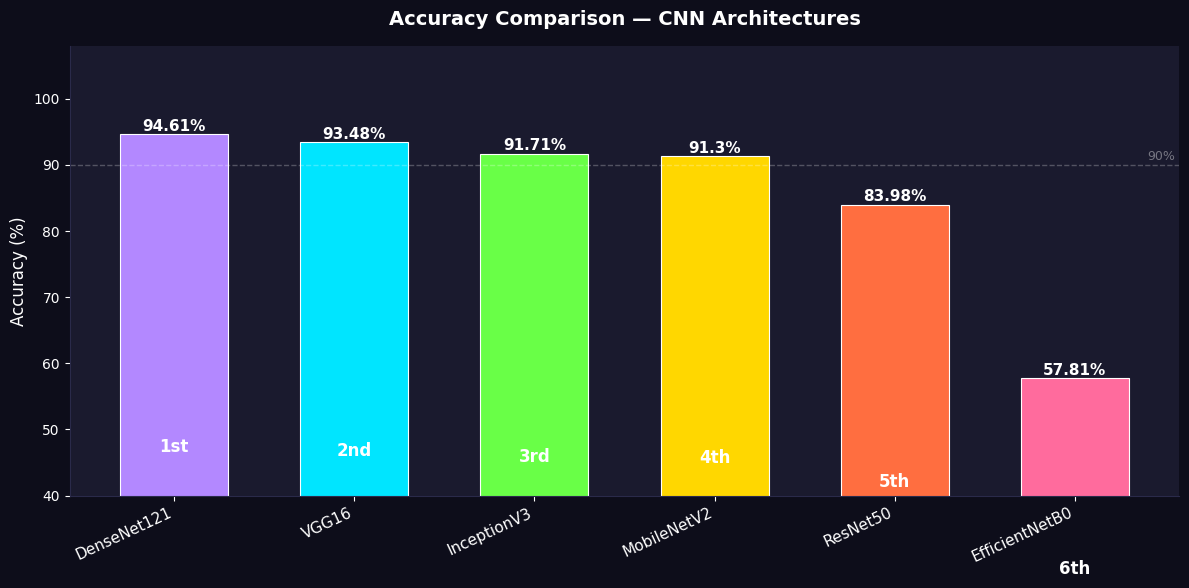

✅ Plot 1 saved!


In [ ]:
# Accuracy
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')
medals = ['4th', '6th', '3rd', '5th', '6th', '1st']

# Sort by accuracy
sorted_idx = df['Accuracy'].sort_values(ascending=False).index
sorted_acc = df['Accuracy'].sort_values(ascending=False).values
sorted_colors = [colors[models.index(m)] for m in sorted_idx]
medals = ['1st','2nd','3rd','4th','5th','6th']

bars = ax.bar(range(len(models)), df.loc[sorted_idx, 'Accuracy'],
              color=sorted_colors, edgecolor='white', linewidth=0.8, width=0.6)

for i, (bar, val, medal) in enumerate(zip(bars, sorted_acc, medals)):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val}%', ha='center', fontsize=11, color='white', fontweight='bold')
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
            medal, ha='center', va='center', fontsize=12, color='white', fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(sorted_idx, rotation=25, ha='right', color='white', fontsize=11)
ax.set_ylim([40, 108])
ax.set_ylabel('Accuracy (%)', color='white', fontsize=12)
ax.set_title('Accuracy Comparison — CNN Architectures', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=90, color='white', linestyle='--', alpha=0.25, linewidth=1)
ax.text(5.4, 90.8, '90%', color='white', alpha=0.4, fontsize=9)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#2A2A4A')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/oral_cancer_models/plot1_accuracy.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Plot 1 saved!")

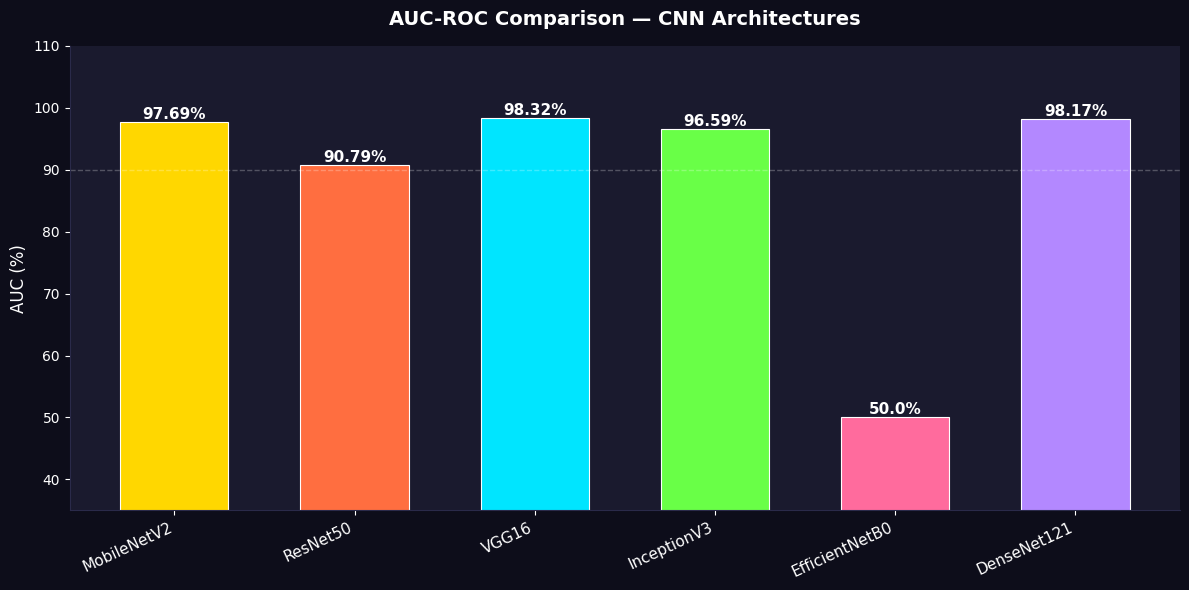

✅ Plot 2 saved!


In [ ]:
# AUC
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

bars = ax.bar(range(len(models)), df['AUC'], color=colors,
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, df['AUC']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val}%', ha='center', fontsize=11, color='white', fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=25, ha='right', color='white', fontsize=11)
ax.set_ylim([35, 110])
ax.set_ylabel('AUC (%)', color='white', fontsize=12)
ax.set_title('AUC-ROC Comparison — CNN Architectures', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=90, color='white', linestyle='--', alpha=0.25, linewidth=1)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#2A2A4A')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/oral_cancer_models/plot2_auc.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Plot 2 saved!")

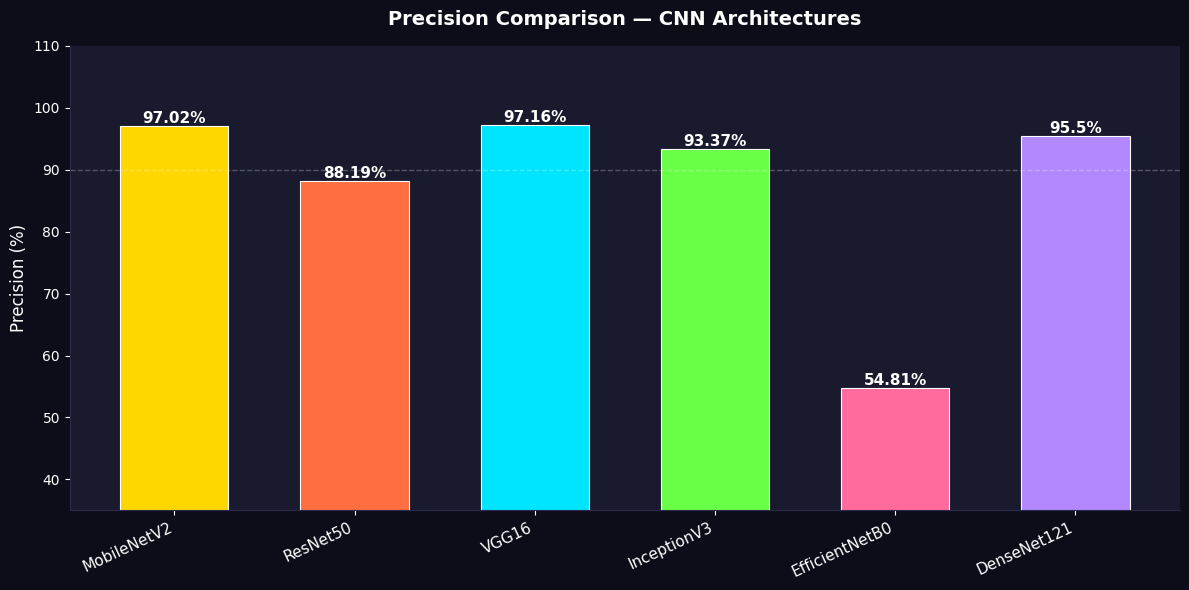

✅ Plot 3 saved!


In [ ]:
# Precision
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

bars = ax.bar(range(len(models)), df['Precision'], color=colors,
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, df['Precision']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val}%', ha='center', fontsize=11, color='white', fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=25, ha='right', color='white', fontsize=11)
ax.set_ylim([35, 110])
ax.set_ylabel('Precision (%)', color='white', fontsize=12)
ax.set_title('Precision Comparison — CNN Architectures', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=90, color='white', linestyle='--', alpha=0.25, linewidth=1)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#2A2A4A')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/oral_cancer_models/plot3_precision.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Plot 3 saved!")

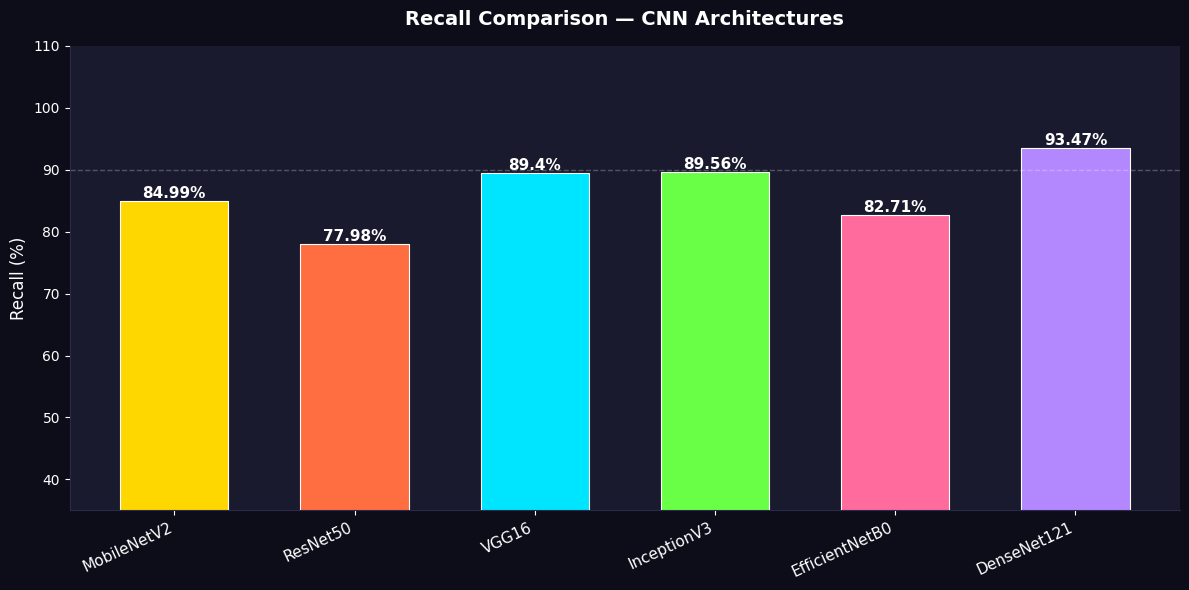

✅ Plot 4 saved!


In [ ]:
# Recall
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

bars = ax.bar(range(len(models)), df['Recall'], color=colors,
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, df['Recall']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val}%', ha='center', fontsize=11, color='white', fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=25, ha='right', color='white', fontsize=11)
ax.set_ylim([35, 110])
ax.set_ylabel('Recall (%)', color='white', fontsize=12)
ax.set_title('Recall Comparison — CNN Architectures', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=90, color='white', linestyle='--', alpha=0.25, linewidth=1)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#2A2A4A')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/oral_cancer_models/plot4_recall.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Plot 4 saved!")

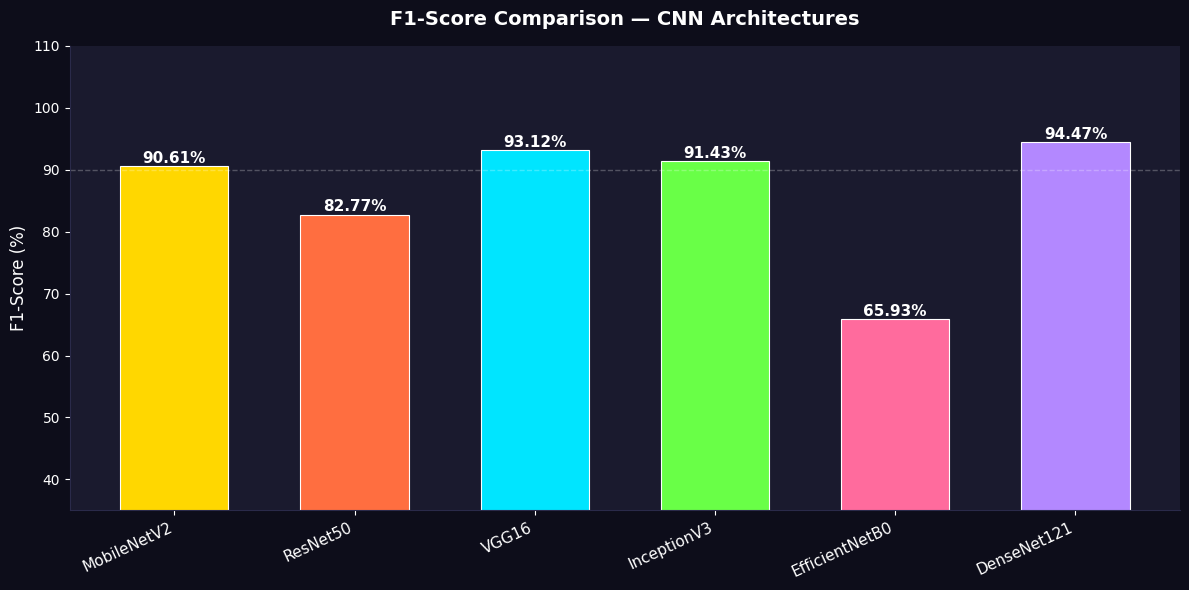

✅ Plot 5 saved!


In [ ]:
# F1-Score
fig, ax = plt.subplots(figsize=(12, 6), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

bars = ax.bar(range(len(models)), df['F1'], color=colors,
              edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, df['F1']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val}%', ha='center', fontsize=11, color='white', fontweight='bold')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=25, ha='right', color='white', fontsize=11)
ax.set_ylim([35, 110])
ax.set_ylabel('F1-Score (%)', color='white', fontsize=12)
ax.set_title('F1-Score Comparison — CNN Architectures', color='white',
             fontsize=14, fontweight='bold', pad=15)
ax.axhline(y=90, color='white', linestyle='--', alpha=0.25, linewidth=1)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#2A2A4A')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/oral_cancer_models/plot5_f1.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Plot 5 saved!")

In [ ]:
# Model Summary
import os
import tensorflow as tf

SAVE_DIR = '/content/drive/MyDrive/oral_cancer_models'

models_info = {
    'MobileNetV2'   : 'MobileNetV2_best.keras',
    'ResNet50'      : 'ResNet50_best.keras',
    'VGG16'         : 'VGG16_best.keras',
    'InceptionV3'   : 'InceptionV3_best.keras',
    'EfficientNetB0': 'EfficientNetB0_best.keras',
    'DenseNet121'   : 'DenseNet121_best.keras',
}

print(f"{'Model':<16} | {'Total Params':>15} | {'Trainable':>12} | {'Frozen':>12} | {'Size on Disk':>12}")
print("="*75)

for model_name, filename in models_info.items():
    filepath = os.path.join(SAVE_DIR, filename)

    if not os.path.exists(filepath):
        print(f"{model_name:<16} | ❌ File not found")
        continue

    tf.keras.backend.clear_session()
    model = tf.keras.models.load_model(filepath)

    total_params     = model.count_params()
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    frozen_params    = total_params - trainable_params
    size_mb          = round(os.path.getsize(filepath) / 1024 / 1024, 2)

    print(f"{model_name:<16} | {total_params:>15,} | {trainable_params:>12,} | {frozen_params:>12,} | {size_mb:>10} MB")

print("="*75)
print("\n✅ Model Summary Complete!")

Model            |    Total Params |    Trainable |       Frozen | Size on Disk
MobileNetV2      |       2,624,065 |      363,521 |    2,260,544 |      13.36 MB
ResNet50         |      24,153,473 |      561,665 |   23,591,808 |      97.07 MB
VGG16            |      14,881,089 |      165,377 |   14,715,712 |      58.13 MB
InceptionV3      |      22,368,545 |      561,665 |   21,806,880 |      90.68 MB
EfficientNetB0   |       4,415,652 |      363,521 |    4,052,131 |      20.44 MB
DenseNet121      |       7,337,025 |      297,473 |    7,039,552 |      31.72 MB

✅ Model Summary Complete!


Evaluating MobileNetV2...
Found 1242 images belonging to 2 classes.
  cancer: 91.9% | non_cancer: 90.61%
Evaluating ResNet50...
Found 1242 images belonging to 2 classes.
  cancer: 85.03% | non_cancer: 82.77%
Evaluating VGG16...
Found 1242 images belonging to 2 classes.
  cancer: 93.8% | non_cancer: 93.12%
Evaluating InceptionV3...
Found 1242 images belonging to 2 classes.
  cancer: 91.97% | non_cancer: 91.42%
Evaluating EfficientNetB0...
Found 1242 images belonging to 2 classes.
  cancer: 44.61% | non_cancer: 65.93%
Evaluating DenseNet121...
Found 1242 images belonging to 2 classes.
  cancer: 94.73% | non_cancer: 94.48%

Per-Class F1 Scores:
                cancer  non_cancer
MobileNetV2      91.90       90.61
ResNet50         85.03       82.77
VGG16            93.80       93.12
InceptionV3      91.97       91.42
EfficientNetB0   44.61       65.93
DenseNet121      94.73       94.48


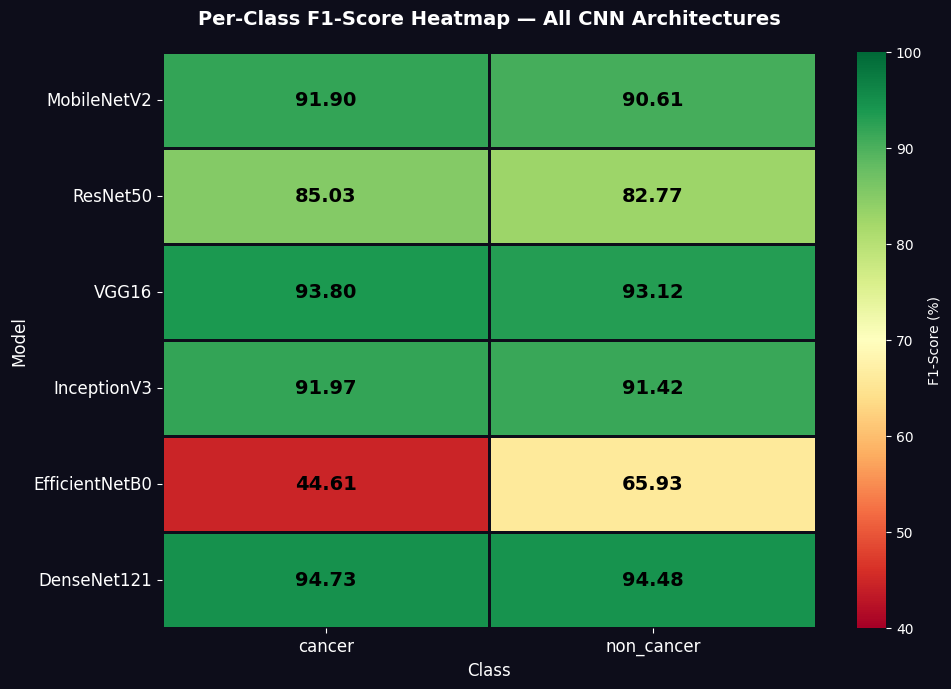

Heatmap saved to Google Drive!


In [ ]:
# Per class Heatmap Across all Models
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

SAVE_DIR     = '/content/drive/MyDrive/oral_cancer_models'
DATASET_PATH = './final_dataset'
BATCH_SIZE   = 32

test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

saved_models = {
    'MobileNetV2'   : ('MobileNetV2_best.keras',    (224, 224)),
    'ResNet50'      : ('ResNet50_best.keras',        (224, 224)),
    'VGG16'         : ('VGG16_best.keras',           (224, 224)),
    'InceptionV3'   : ('InceptionV3_best.keras',     (299, 299)),
    'EfficientNetB0': ('EfficientNetB0_best.keras',  (224, 224)),
    'DenseNet121'   : ('DenseNet121_best.keras',     (224, 224)),
}

f1_data = {}

for model_name, (filename, img_size) in saved_models.items():
    filepath = os.path.join(SAVE_DIR, filename)

    if not os.path.exists(filepath):
        print(f"❌ {model_name} not found, skipping...")
        continue

    print(f"Evaluating {model_name}...")
    tf.keras.backend.clear_session()
    model = tf.keras.models.load_model(filepath)

    val_gen = test_datagen.flow_from_directory(
        DATASET_PATH, target_size=img_size, batch_size=BATCH_SIZE,
        class_mode='binary', subset='validation', seed=42, shuffle=False
    )
    val_gen.reset()

    preds   = (model.predict(val_gen, verbose=0) > 0.5).astype(int).flatten()
    labels  = val_gen.classes
    classes = list(val_gen.class_indices.keys())

    report = classification_report(labels, preds,
                                   target_names=classes, output_dict=True)

    f1_data[model_name] = {
        classes[0]: round(report[classes[0]]['f1-score'] * 100, 2),
        classes[1]: round(report[classes[1]]['f1-score'] * 100, 2),
    }
    print(f"  {classes[0]}: {f1_data[model_name][classes[0]]}% | "
          f"{classes[1]}: {f1_data[model_name][classes[1]]}%")

# ── Build DataFrame ─────────────────────────────────
df_f1 = pd.DataFrame(f1_data).T
print("\nPer-Class F1 Scores:")
print(df_f1.round(2))

# ── Plot Heatmap ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

sns.heatmap(
    df_f1,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    linewidths=0.8,
    linecolor='#0D0D1A',
    vmin=40, vmax=100,
    annot_kws={'size': 14, 'weight': 'bold', 'color': 'black'},
    ax=ax,
    cbar_kws={'label': 'F1-Score (%)'}
)

ax.set_title('Per-Class F1-Score Heatmap — All CNN Architectures',
             color='white', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Class', color='white', fontsize=12)
ax.set_ylabel('Model', color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=12)

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.label.set_color('white')
cbar.ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/oral_cancer_models/per_class_f1_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("Heatmap saved to Google Drive!")

# Quantum Inspired DenseNet121

In [ ]:
!pip install pennylane --quiet
!pip install pennylane-lightning --quiet

import pennylane as qml
print(f"✅ PennyLane version: {qml.__version__}")
print("✅ All dependencies installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 80.5 MB/s eta 0:00:00
✅ PennyLane version: 0.44.1
✅ All dependencies installed!


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import pennylane as qml
from pennylane import numpy as pnp
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_curve, auc)
from tensorflow.keras.layers import (Dense, GlobalAveragePooling2D, Dropout,
                                      BatchNormalization, Multiply, Reshape,
                                      Conv2D, Add, Activation, Lambda,
                                      GlobalMaxPooling2D, Concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                                         ModelCheckpoint)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# ── Constants ──────────────────────────────────────
DATASET_PATH = './final_dataset'
SAVE_DIR     = '/content/drive/MyDrive/oral_cancer_models'
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
EPOCHS       = 50
N_QUBITS     = 4   # number of qubits in VQC
N_LAYERS     = 2   # number of variational layers

print(f"✅ TensorFlow : {tf.__version__}")
print(f"✅ PennyLane  : {qml.__version__}")
print(f"✅ Qubits     : {N_QUBITS}")
print(f"✅ VQC Layers : {N_LAYERS}")
print("✅ All imports successful!")

✅ TensorFlow : 2.19.0
✅ PennyLane  : 0.44.1
✅ Qubits     : 4
✅ VQC Layers : 2
✅ All imports successful!


In [ ]:
# Load Dataset & Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='training', seed=42
)
val_gen = test_datagen.flow_from_directory(
    DATASET_PATH, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='binary', subset='validation', seed=42, shuffle=False
)

print(f"\n📦 Training samples   : {train_gen.samples}")
print(f"📦 Validation samples : {val_gen.samples}")
print(f"🏷️  Classes            : {train_gen.class_indices}")

Found 4958 images belonging to 2 classes.
Found 1238 images belonging to 2 classes.

📦 Training samples   : 4958
📦 Validation samples : 1238
🏷️  Classes            : {'cancer': 0, 'non_cancer': 1}


In [ ]:
# SE Block (Squeeze & Excitation)
def se_block(inputs, ratio=16):
    """
    Squeeze & Excitation Block
    - Squeeze  : GlobalAveragePooling → channel descriptor
    - Excitation: Dense → ReLU → Dense → Sigmoid → scale channels
    """
    filters = inputs.shape[-1]

    # Squeeze
    se = GlobalAveragePooling2D()(inputs)
    se = Reshape((1, 1, filters))(se)

    # Excitation
    se = Dense(filters // ratio, activation='relu',
               kernel_initializer='he_normal', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid',
               kernel_initializer='he_normal', use_bias=False)(se)

    # Scale
    output = Multiply()([inputs, se])
    return output

print("✅ SE Block defined!")
print("   Squeeze  → GlobalAvgPool → channel descriptor")
print("   Excite   → Dense(relu) → Dense(sigmoid)")
print("   Scale    → Multiply input × attention weights")

✅ SE Block defined!
   Squeeze  → GlobalAvgPool → channel descriptor
   Excite   → Dense(relu) → Dense(sigmoid)
   Scale    → Multiply input × attention weights


In [ ]:
# CBAM Block
def channel_attention(inputs, ratio=16):
    """Channel Attention Module"""
    filters = inputs.shape[-1]

    # Average pool path
    avg_pool = GlobalAveragePooling2D()(inputs)
    avg_pool = Reshape((1, 1, filters))(avg_pool)
    avg_pool = Dense(filters // ratio, activation='relu', use_bias=False)(avg_pool)
    avg_pool = Dense(filters, use_bias=False)(avg_pool)

    # Max pool path
    max_pool = GlobalMaxPooling2D()(inputs)
    max_pool = Reshape((1, 1, filters))(max_pool)
    max_pool = Dense(filters // ratio, activation='relu', use_bias=False)(max_pool)
    max_pool = Dense(filters, use_bias=False)(max_pool)

    # Combine & sigmoid
    combined = Add()([avg_pool, max_pool])
    attention = Activation('sigmoid')(combined)
    return Multiply()([inputs, attention])

def spatial_attention(inputs, kernel_size=7):
    """Spatial Attention Module"""
    # Average & max across channels
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(inputs)
    max_pool = Lambda(lambda x: tf.reduce_max(x,  axis=-1, keepdims=True))(inputs)

    # Concatenate & convolve
    concat    = Concatenate(axis=-1)([avg_pool, max_pool])
    attention = Conv2D(1, kernel_size=kernel_size, padding='same',
                       activation='sigmoid', use_bias=False)(concat)
    return Multiply()([inputs, attention])

def cbam_block(inputs, ratio=16, kernel_size=7):
    """
    Full CBAM = Channel Attention + Spatial Attention
    """
    x = channel_attention(inputs, ratio)
    x = spatial_attention(x, kernel_size)
    return x

print("✅ CBAM Block defined!")
print("   Channel Attention → what features to focus on")
print("   Spatial Attention → where in the image to focus")

✅ CBAM Block defined!
   Channel Attention → what features to focus on
   Spatial Attention → where in the image to focus


In [ ]:
# VQC Layer (PennyLane)
# ── Quantum Device ──────────────────────────────────
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, interface='tf', diff_method='backprop')
def quantum_circuit(inputs, weights):
    """
    VQC Architecture:
    1. AngleEmbedding  → encode classical features as rotation angles
    2. StronglyEntanglingLayers → variational + entanglement layers
    3. Measure PauliZ expectation on each qubit
    """
    # Encode input features as rotation angles
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation='Y')

    # Variational layers with entanglement
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))

    # Measure expectation values
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

# ── Keras-compatible VQC Layer ──────────────────────
class VQCLayer(tf.keras.layers.Layer):
    def __init__(self, n_qubits, n_layers, **kwargs):
        super(VQCLayer, self).__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        weight_shape = qml.StronglyEntanglingLayers.shape(
            n_layers=self.n_layers, n_wires=self.n_qubits
        )
        self.quantum_weights = self.add_weight(
            name='quantum_weights',
            shape=weight_shape,
            initializer='glorot_uniform',
            trainable=True
        )

    def call(self, inputs):
        # Process each sample in batch
        def run_circuit(x):
            return tf.cast(quantum_circuit(x, self.quantum_weights), dtype=tf.float32)

        return tf.map_fn(run_circuit, inputs, fn_output_signature=tf.float32)

    def get_config(self):
        config = super().get_config()
        config.update({'n_qubits': self.n_qubits, 'n_layers': self.n_layers})
        return config

print("✅ VQC Layer defined!")
print(f"   Qubits  : {N_QUBITS}")
print(f"   Layers  : {N_LAYERS}")
print(f"   Encoding: AngleEmbedding (RY rotations)")
print(f"   Circuit : StronglyEntanglingLayers")
print(f"   Output  : PauliZ expectation values")

✅ VQC Layer defined!
   Qubits  : 4
   Layers  : 2
   Encoding: AngleEmbedding (RY rotations)
   Circuit : StronglyEntanglingLayers
   Output  : PauliZ expectation values


In [ ]:
import pennylane as qml
import tensorflow as tf
import numpy as np

N_QUBITS = 4
N_LAYERS = 2

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="tf", diff_method="backprop")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]


class VQCLayer(tf.keras.layers.Layer):
    def __init__(self, n_qubits=N_QUBITS, n_layers=N_LAYERS, **kwargs):
        super().__init__(**kwargs)
        self.n_qubits = n_qubits
        self.n_layers = n_layers

    def build(self, input_shape):
        weight_shape = qml.StronglyEntanglingLayers.shape(
            n_layers=self.n_layers, n_wires=self.n_qubits
        )
        self.quantum_weights = self.add_weight(
            name="quantum_weights",
            shape=weight_shape,
            initializer="glorot_uniform",
            trainable=True,
            dtype=tf.float32
        )
        super().build(input_shape)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.n_qubits)

    def call(self, inputs):                                      # ← 4 spaces
        inputs  = tf.cast(inputs, dtype=tf.float32)             # ← 8 spaces
        weights = tf.cast(self.quantum_weights, dtype=tf.float32)

        def run_single(x):                                       # ← 8 spaces
            result    = quantum_circuit(x, weights)              # ← 12 spaces
            stacked   = tf.stack(result)
            real_part = tf.math.real(stacked)
            return tf.cast(real_part, dtype=tf.float32)

        output = tf.vectorized_map(run_single, inputs)           # ← 8 spaces
        return tf.cast(output, dtype=tf.float32)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"n_qubits": self.n_qubits, "n_layers": self.n_layers})
        return cfg

In [ ]:
def build_qi_densenet121(input_shape=(224, 224, 3)):

    inputs = tf.keras.Input(shape=input_shape)

    # ── 1. DenseNet121 Backbone (frozen) ───────────
    base = DenseNet121(weights='imagenet', include_top=False,
                       input_tensor=inputs)
    for layer in base.layers:
        layer.trainable = False
    x = base.output

    # ── 2. SE Block ────────────────────────────────
    x = se_block(x, ratio=16)

    # ── 3. CBAM Block ──────────────────────────────
    x = cbam_block(x, ratio=16, kernel_size=7)

    # ── 4. Global Average Pooling ──────────────────
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)

    # ── 5. Classical Dense ─────────────────────────
    x = Dense(256, activation='relu',
              kernel_initializer='he_normal')(x)
    x = Dropout(0.4)(x)

    # ── 6. Reduce to N_QUBITS for VQC input ────────
    x = Dense(N_QUBITS, activation='tanh')(x)  # tanh keeps values in [-1,1] for angle encoding

    # ── 7. VQC Layer ───────────────────────────────
    x = VQCLayer(n_qubits=N_QUBITS, n_layers=N_LAYERS, name='VQC')(x)

    # ── 8. Classical Head ──────────────────────────
    x = Dense(64, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # ── 9. Output ──────────────────────────────────
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=output, name='QI_DenseNet121')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy',
                 tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

qi_model = build_qi_densenet121()
print("✅ QI-DenseNet121 built successfully!")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
✅ QI-DenseNet121 built successfully!


In [ ]:
# Model Summary
qi_model.summary()

total_params     = qi_model.count_params()
trainable_params = sum([tf.size(w).numpy() for w in qi_model.trainable_weights])
frozen_params    = total_params - trainable_params

print(f"\n{'='*45}")
print(f"  Total Parameters     : {total_params:>12,}")
print(f"  Trainable Parameters : {trainable_params:>12,}")
print(f"  Frozen Parameters    : {frozen_params:>12,}")
print(f"{'='*45}")
print(f"\n Architecture:")
print(f"  DenseNet121 Backbone  → Feature Extraction")
print(f"  SE Block              → Channel Attention")
print(f"  CBAM Block            → Channel + Spatial Attention")
print(f"  VQC ({N_QUBITS} qubits, {N_LAYERS} layers) → Quantum Feature Processing")
print(f"  Classical Head        → Binary Classification")

Model: "QI_DenseNet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,699,007 (29.37 MB)

 Trainable params: 659,327 (2.52 MB)

 Non-trainable params: 7,039,680 (26.85 MB)


  Total Parameters     :    7,699,007
  Trainable Parameters :      659,327
  Frozen Parameters    :    7,039,680

 Architecture:
  DenseNet121 Backbone  → Feature Extraction
  SE Block              → Channel Attention
  CBAM Block            → Channel + Spatial Attention
  VQC (4 qubits, 2 layers) → Quantum Feature Processing
  Classical Head        → Binary Classification


In [ ]:
# Train
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                      patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint(f'{SAVE_DIR}/QI_DenseNet121_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("Starting QI-DenseNet121 Training...")
print(f"Epochs        : {EPOCHS}")
print(f"Batch Size    : {BATCH_SIZE}")
print(f"Training on   : {train_gen.samples} images")
print(f"Validating on : {val_gen.samples} images")
print("="*45)

history = qi_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)
print("\nTraining Complete!")

Starting QI-DenseNet121 Training...
Epochs        : 50
Batch Size    : 32
Training on   : 4958 images
Validating on : 1238 images
Epoch 1/50


155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7228 - auc: 0.7999 - loss: 0.5270 - precision: 0.7422 - recall: 0.6787
Epoch 1: val_accuracy improved from None to 0.54120, saving model to /content/drive/MyDrive/oral_cancer_models/QI_DenseNet121_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/oral_cancer_models/QI_DenseNet121_best.keras
155/155 ━━━━━━━━━━━━━━━━━━━━ 1326s 8s/step - accuracy: 0.7900 - auc: 0.8735 - loss: 0.4453 - precision: 0.7985 - recall: 0.7668 - val_accuracy: 0.5412 - val_auc: 0.8940 - val_loss: 0.6739 - val_precision: 1.0000 - val_recall: 0.0673 - learning_rate: 0.0010
Epoch 2/50
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.8476 - auc: 0.9180 - loss: 0.3617 - precision: 0.8551 - recall: 0.8209
Epoch 2: val_accuracy improved from 0.54120 to 0.86349, saving model to /content/drive/MyDrive/oral_cancer_models/QI_DenseNet121_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/oral_cancer_models/QI_DenseNet121_best.keras

In [ ]:
# Save to Google Drive
save_path = f'{SAVE_DIR}/QI_DenseNet121_best.keras'
qi_model.save(save_path)

size_mb = round(os.path.getsize(save_path) / 1024 / 1024, 2)
print(f"✅ QI-DenseNet121 saved to Google Drive!")
print(f"   Path    : {save_path}")
print(f"   Size    : {size_mb} MB")

# Verify
loaded = tf.keras.models.load_model(
    save_path,
    custom_objects={'VQCLayer': VQCLayer}
)
print(f"   Model   : {loaded.name}")
print(f"   Verified!")

In [ ]:
# Evaluate
from sklearn.metrics import classification_report

tf.keras.backend.clear_session()
qi_model = tf.keras.models.load_model(
    f'{SAVE_DIR}/QI_DenseNet121_best.keras',
    custom_objects={'VQCLayer': VQCLayer}
)

val_gen.reset()
preds  = (qi_model.predict(val_gen, verbose=1) > 0.5).astype(int).flatten()
labels = val_gen.classes
classes = list(val_gen.class_indices.keys())

report = classification_report(labels, preds,
                                target_names=classes, output_dict=True)

print(f"\n📊 QI-DenseNet121 Results:")
print(f"  Accuracy  : {report['accuracy']*100:.2f}%")
print(f"  Precision : {report['weighted avg']['precision']*100:.2f}%")
print(f"  Recall    : {report['weighted avg']['recall']*100:.2f}%")
print(f"  F1-Score  : {report['weighted avg']['f1-score']*100:.2f}%")
print(f"\nPer-Class Results:")
for cls in classes:
    print(f"  {cls:12s} → Precision: {report[cls]['precision']*100:.2f}% | "
          f"Recall: {report[cls]['recall']*100:.2f}% | "
          f"F1: {report[cls]['f1-score']*100:.2f}%")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(labels, preds)
classes = list(val_gen.class_indices.keys())

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes,
            linewidths=1, linecolor='#0D0D1A',
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=ax)

ax.set_title('Confusion Matrix — QI-DenseNet121',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', color='white', fontsize=12)
ax.set_ylabel('True Label',      color='white', fontsize=12)
ax.tick_params(colors='white', labelsize=11)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix_QI_DenseNet121.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print("✅ Confusion Matrix saved!")

In [ ]:
# ROC Curve
val_gen.reset()
probs  = qi_model.predict(val_gen, verbose=0).flatten()
labels = val_gen.classes

fpr, tpr, _ = roc_curve(labels, probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

ax.plot(fpr, tpr, color='#FFD700', linewidth=2.5,
        label=f'QI-DenseNet121 (AUC = {roc_auc:.4f})')
ax.plot([0,1], [0,1], color='white', linestyle='--',
        linewidth=1, alpha=0.4, label='Random Classifier')

ax.fill_between(fpr, tpr, alpha=0.15, color='#FFD700')

ax.set_xlabel('False Positive Rate', color='white', fontsize=12)
ax.set_ylabel('True Positive Rate',  color='white', fontsize=12)
ax.set_title('ROC Curve — QI-DenseNet121',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=11)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#2A2A4A')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curve_QI_DenseNet121.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print(f"✅ ROC Curve saved! AUC = {roc_auc:.4f}")

In [ ]:
# Grad-CAM
val_gen.reset()
probs  = qi_model.predict(val_gen, verbose=0).flatten()
labels = val_gen.classes

fpr, tpr, _ = roc_curve(labels, probs)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 7), facecolor='#0D0D1A')
ax.set_facecolor('#1A1A2E')

ax.plot(fpr, tpr, color='#FFD700', linewidth=2.5,
        label=f'QI-DenseNet121 (AUC = {roc_auc:.4f})')
ax.plot([0,1], [0,1], color='white', linestyle='--',
        linewidth=1, alpha=0.4, label='Random Classifier')

ax.fill_between(fpr, tpr, alpha=0.15, color='#FFD700')

ax.set_xlabel('False Positive Rate', color='white', fontsize=12)
ax.set_ylabel('True Positive Rate',  color='white', fontsize=12)
ax.set_title('ROC Curve — QI-DenseNet121',
             color='white', fontsize=14, fontweight='bold', pad=15)
ax.legend(facecolor='#1A1A2E', labelcolor='white', fontsize=11)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#2A2A4A')

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curve_QI_DenseNet121.png',
            dpi=150, bbox_inches='tight', facecolor='#0D0D1A')
plt.show()
print(f"✅ ROC Curve saved! AUC = {roc_auc:.4f}")

In [ ]:
# Final Comparison Table
comparison = {
    'DenseNet121 (Baseline)': {
        'Accuracy' : 94.61,
        'AUC'      : 98.17,
        'Precision': 95.50,
        'Recall'   : 93.47,
        'F1'       : round(2*95.50*93.47/(95.50+93.47), 2)
    },
    'QI-DenseNet121 (Proposed)': {
        'Accuracy' : 0.00,  # replace after Cell 11
        'AUC'      : 0.00,
        'Precision': 0.00,
        'Recall'   : 0.00,
        'F1'       : 0.00,
    }
}

df_compare = pd.DataFrame(comparison).T
print("\n" + "="*65)
print("   FINAL COMPARISON: DenseNet121 vs QI-DenseNet121")
print("="*65)
print(df_compare.to_string())
print("="*65)

# Improvement
for metric in ['Accuracy','AUC','Precision','Recall','F1']:
    baseline = df_compare.loc['DenseNet121 (Baseline)', metric]
    proposed = df_compare.loc['QI-DenseNet121 (Proposed)', metric]
    diff     = proposed - baseline
    arrow    = "↑" if diff > 0 else "↓"
    print(f"  {metric:10s}: {arrow} {abs(diff):.2f}%")